In [24]:
from logging import exception
#Mount the googledrive to access files
try:
  from google.colab import drive
  drive.mount('/content/drive')
except exception as ex:
  print("An error occured: ", ex)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
#Load the dataset and demonstrate the successful loading of the dataset by displaying both the top and bottom five rows.
import pandas as pd

try:
  filepath = '/content/drive/MyDrive/43031/Assessment_Task3/deliveries.csv' #shows the file path
  deliveries_dataset = pd.read_csv(filepath, header=0)
  print("Dataset successfully loaded.")

  print("Top 5 rows: ")
  print(deliveries_dataset.head()) #displaying top 5 rows to show that the dataset is loaded

except Exception as ex: #exception handling
    print("An error occurred:", ex)


Dataset successfully loaded.
Top 5 rows: 
   match_no          date         stage                  venue batting_team  \
0         1  Mar 22, 2025  League stage  Eden Gardens, Kolkata          KKR   
1         1  Mar 22, 2025  League stage  Eden Gardens, Kolkata          KKR   
2         1  Mar 22, 2025  League stage  Eden Gardens, Kolkata          KKR   
3         1  Mar 22, 2025  League stage  Eden Gardens, Kolkata          KKR   
4         1  Mar 22, 2025  League stage  Eden Gardens, Kolkata          KKR   

  bowling_team  innings  over  striker     bowler  runs_of_bat  extras  wide  \
0          RCB        1   0.1  de Kock  Hazlewood            0       0   0.0   
1          RCB        1   0.2  de Kock  Hazlewood            4       0   0.0   
2          RCB        1   0.3  de Kock  Hazlewood            0       0   0.0   
3          RCB        1   0.4  de Kock  Hazlewood            0       0   0.0   
4          RCB        1   0.5  de Kock  Hazlewood            0       0   0.0   

  

In [35]:
# Check the column names
print(deliveries_dataset.columns.values)


['match_no' 'date' 'stage' 'venue' 'batting_team' 'bowling_team' 'innings'
 'over' 'striker' 'bowler' 'runs_of_bat' 'extras' 'wide' 'legbyes' 'byes'
 'noballs' 'wicket_type' 'player_dismissed' 'fielder']


In [36]:
#renaming the column names for better readability
try:
  deliveries_dataset.rename(columns={
      'runs_of_bat': 'runs_scored_by_batsman',
      'match_no': 'match_number',
      'extras': 'extra_runs',
  }, inplace=True)

  print(deliveries_dataset.columns.values) #cross checking the rename changes
except Exception as ex:
  print("An error occured: ", ex)

['match_number' 'date' 'stage' 'venue' 'batting_team' 'bowling_team'
 'innings' 'over' 'striker' 'bowler' 'runs_scored_by_batsman' 'extra_runs'
 'wide' 'legbyes' 'byes' 'noballs' 'wicket_type' 'player_dismissed'
 'fielder']


In [37]:
#displaying the datatype of the columns
try:
  print("The datatype of the columns: ")
  print(deliveries_dataset.dtypes)

  # Convert 'date' column to datetime
  deliveries_dataset['date'] = pd.to_datetime(deliveries_dataset['date'])

  # Check the data types
  print(deliveries_dataset['date'].dtypes)
except Exception as ex:
  print("An error occured: ", ex)


The datatype of the columns: 
match_number                int64
date                       object
stage                      object
venue                      object
batting_team               object
bowling_team               object
innings                     int64
over                      float64
striker                    object
bowler                     object
runs_scored_by_batsman      int64
extra_runs                  int64
wide                      float64
legbyes                     int64
byes                        int64
noballs                   float64
wicket_type                object
player_dismissed           object
fielder                    object
dtype: object
datetime64[ns]


In [38]:
print("Duplicates: " ,deliveries_dataset.duplicated().sum()) # check for duplicates

print("Null values: ", deliveries_dataset.isnull()) #check for null values

print("Null values present in: ", deliveries_dataset.isnull().sum()) #gives actual count of null values


Duplicates:  6
Null values:        match_number   date  stage  venue  batting_team  bowling_team  innings  \
0            False  False  False  False         False         False    False   
1            False  False  False  False         False         False    False   
2            False  False  False  False         False         False    False   
3            False  False  False  False         False         False    False   
4            False  False  False  False         False         False    False   
...            ...    ...    ...    ...           ...           ...      ...   
2844         False  False  False  False         False         False    False   
2845         False  False  False  False         False         False    False   
2846         False  False  False  False         False         False    False   
2847         False  False  False  False         False         False    False   
2848         False  False  False  False         False         False    False   

       ove

In [39]:
print(deliveries_dataset.shape) #check for number of rows and columns
try:
  deliveries_dataset.drop_duplicates(inplace=True) #drop duplicates
except Exception as ex:
  print("An error occured: ", ex)
print(deliveries_dataset.shape) #check for number of rows and columns

(2849, 19)
(2843, 19)


In [40]:
deliveries_cleaned = deliveries_dataset.drop(columns=['wicket_type', 'player_dismissed', 'fielder', 'match_number','date']) #Removing columns which are having null values
print(deliveries_cleaned.shape)



(2843, 14)


In [42]:
#Impute the missing values based on their attrbiute
try:
  # Iterate over columns
  for col in deliveries_cleaned.columns:
    if deliveries_cleaned[col].dtype == 'object':
      mode_val = deliveries_cleaned[col].mode()[0] #calculate mode
      deliveries_cleaned[col] = deliveries_cleaned[col].fillna(mode_val) #Impute missihng values with mode
    else:
      mean_val = deliveries_cleaned[col].mean() #Calculate mean
      deliveries_cleaned[col] = deliveries_cleaned[col].fillna(mean_val) #Impute missing values with mean

  print(deliveries_cleaned.isnull().sum())
except Exception as ex:
  print("An error occured: ", ex)

stage                     0
venue                     0
batting_team              0
bowling_team              0
innings                   0
over                      0
striker                   0
bowler                    0
runs_scored_by_batsman    0
extra_runs                0
wide                      0
legbyes                   0
byes                      0
noballs                   0
dtype: int64


In [43]:
try:
  unique_values = deliveries_cleaned['bowler'].unique() #Getting all the unique names in the column bowler
  print(unique_values)
  deliveries_cleaned['bowler'] = deliveries_cleaned['bowler'].replace({'Yash': 'Yash Dayal'}) #Replacing the incorrect name
except Exception as ex:
  print("An error occured: ", ex)

['Hazlewood' 'Yash Dayal' 'Yash' 'Rasikh Salam' 'Krunal Pandya'
 'Suyash Sharma' 'Livingstone' 'Vaibhav Arora' 'Spencer Johnson'
 'Varun Chakaravarthy' 'Harshit Rana' 'Narine' 'Fazalhaq Farooqi'
 'Theekshana' 'Jofra Archer' 'Sandeep Sharma' 'Nitish Rana'
 'Tushar Deshpande' 'Shami' 'Simarjeet Singh' 'Cummins' 'Abhishek Sharma'
 'Zampa' 'Harshal Patel' 'Khaleel Ahmed' 'Sam Curran' 'Nathan Ellis'
 'Ashwin' 'Jadeja' 'Noor Ahmad' 'Boult' 'Chahar' 'Satyanarayana Raju'
 'Santner' 'Will Jacks' 'Vignesh Puthur' 'Naman Dhir' 'Mitchell Starc'
 'Axar' 'Vipraj Nigam' 'Mukesh Kumar' 'Kuldeep Yadav' 'Mohit Sharma'
 'Stubbs' 'Thakur' 'M Siddharth' 'Digvesh Rathi' 'Ravi Bishnoi'
 'Prince Yadav' 'Shahbaz Ahmed' 'Siraj' 'Rabada' 'Arshad Khan'
 'Rashid Khan' 'Prasidh' 'Sai Kishore' 'Arshdeep Singh' 'Azmatullah'
 'Marco Jansen' 'Maxwell' 'Stoinis' 'Chahal' 'Vijaykumar Vyshak'
 'Moeen Ali' 'Riyan Parag' 'Hasaranga' 'Avesh Khan' 'Ishan Kishan'
 'Pathirana' 'Bhuvneshwar' 'Mujeeb' 'Hardik Pandya' 'Ishant'
 'Z

In [12]:
#Remove all the rows with outliers
# Function to remove outliers from all numeric attributes
import numpy as np #importing numpy

try:
  print(deliveries_cleaned.shape)
  def remove_outliers(deliveries_cleaned):
      cleaned_df = deliveries_cleaned.copy() #backup of the dataset
      for col in cleaned_df.select_dtypes(include=["number"]).columns: #iterate over numeric columns
          Q1 = np.percentile(cleaned_df[col], 25)
          Q3 = np.percentile(cleaned_df[col], 75)
          IQR = Q3 - Q1 #Interquartile Range method
          lower_bound = Q1 - 1.5 * IQR
          upper_bound = Q3 + 1.5 * IQR
          cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
      return cleaned_df

  # Remove outliers from DataFrame
  deliveries_cleaned_new = remove_outliers(deliveries_cleaned)
  print(deliveries_cleaned_new.shape)
except Exception as ex:
  print("An error occured: ", ex)

(2843, 14)
(2429, 14)


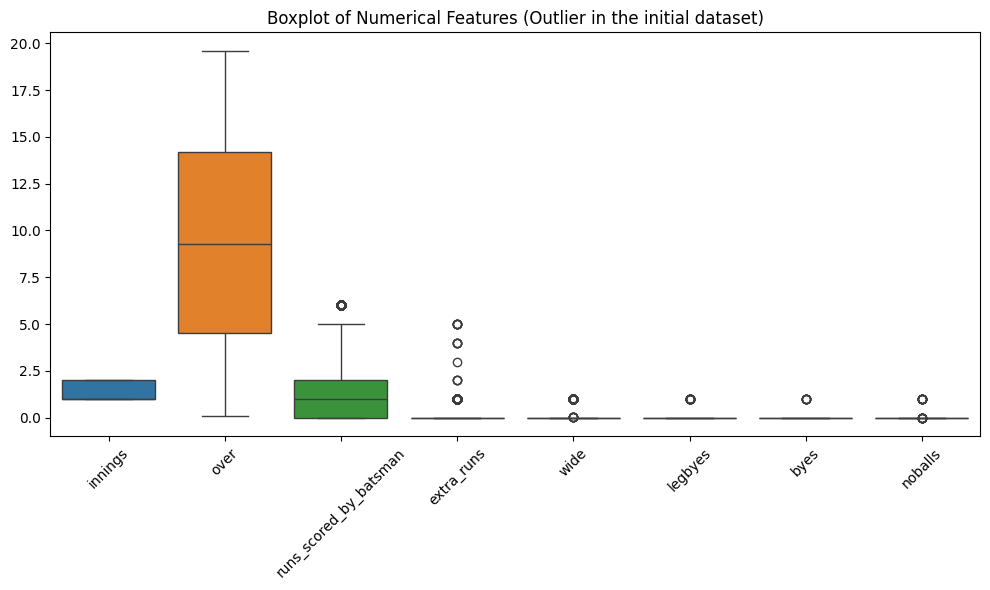

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot to visualize outliers in the initial dataset
try:
  plt.figure(figsize=(10, 6))
  sns.boxplot(data=deliveries_cleaned.select_dtypes(include=['number']))
  plt.title("Boxplot of Numerical Features (Outlier in the initial dataset)")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
except Exception as ex:
  print("An error occured: ", ex)

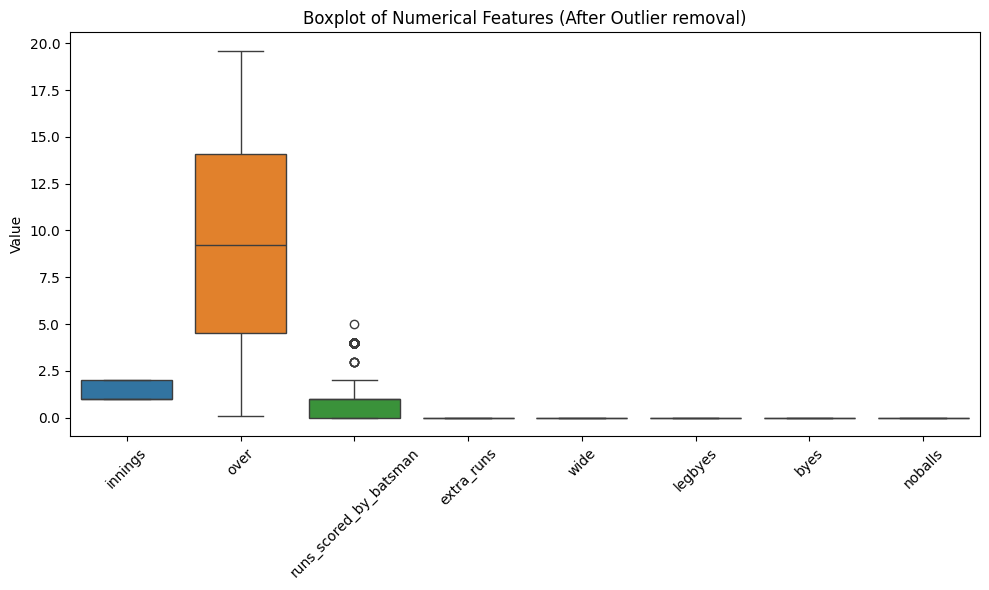

In [14]:
# Boxplot to visualize outliers after removal
try:
  plt.figure(figsize=(10, 6))
  sns.boxplot(data=deliveries_cleaned_new.select_dtypes(include=['number']))
  plt.title("Boxplot of Numerical Features (After Outlier removal)")
  plt.xticks(rotation=45)
  plt.ylabel('Value')
  plt.tight_layout()
  plt.show()
except Exception as ex:
  print("An error occured: ", ex)

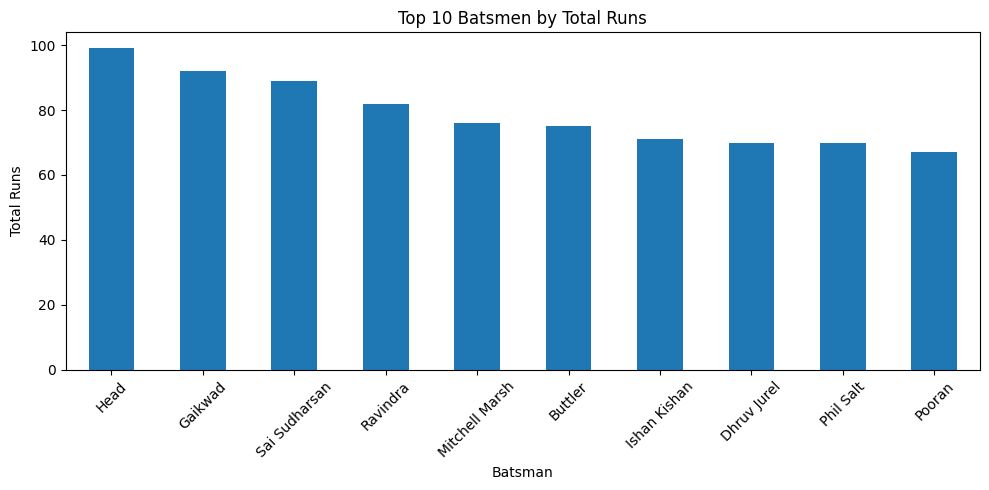

In [15]:
#Business Questions and Visualizations

#1 : Top 10 batsmen by total runs
try:
  plt.figure(figsize=(10, 5))
  top_batsmen = deliveries_cleaned_new.groupby('striker')['runs_scored_by_batsman'].sum().sort_values(ascending=False).head(10)
  top_batsmen.plot(kind='bar', title='Top 10 Batsmen by Total Runs')
  plt.xlabel('Batsman')
  plt.ylabel('Total Runs')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
except Exception as ex:
  print("An error occured: ", ex)

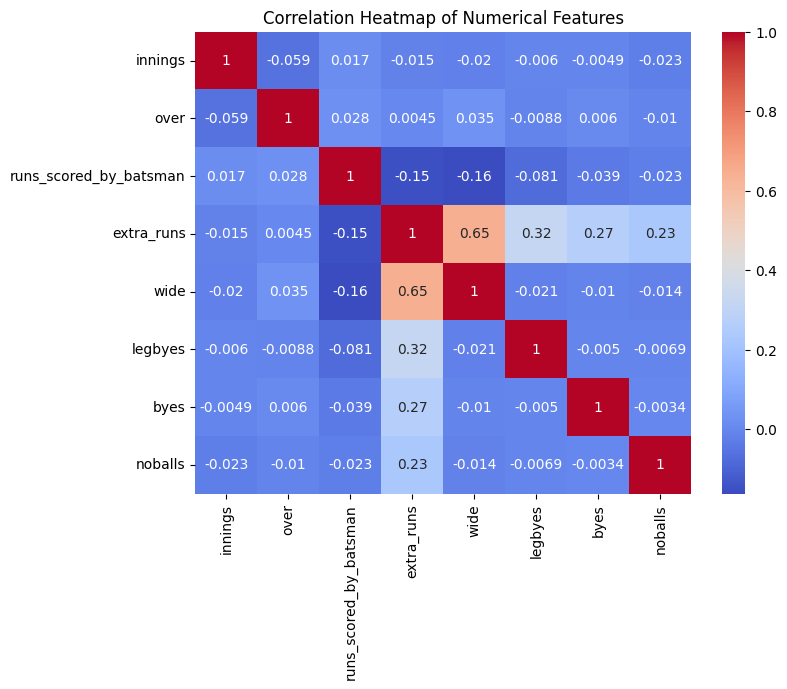

In [16]:
#2: Correlation heatmap between numerical attributes
try:
  plt.figure(figsize=(8, 6))
  numeric_cols = deliveries_cleaned.select_dtypes(include=['number']).columns
  corr = deliveries_cleaned[numeric_cols].corr()
  sns.heatmap(corr, annot=True, cmap='coolwarm')
  plt.title("Correlation Heatmap of Numerical Features")
  plt.show()
except Exception as ex:
  print("An error occured: ", ex)

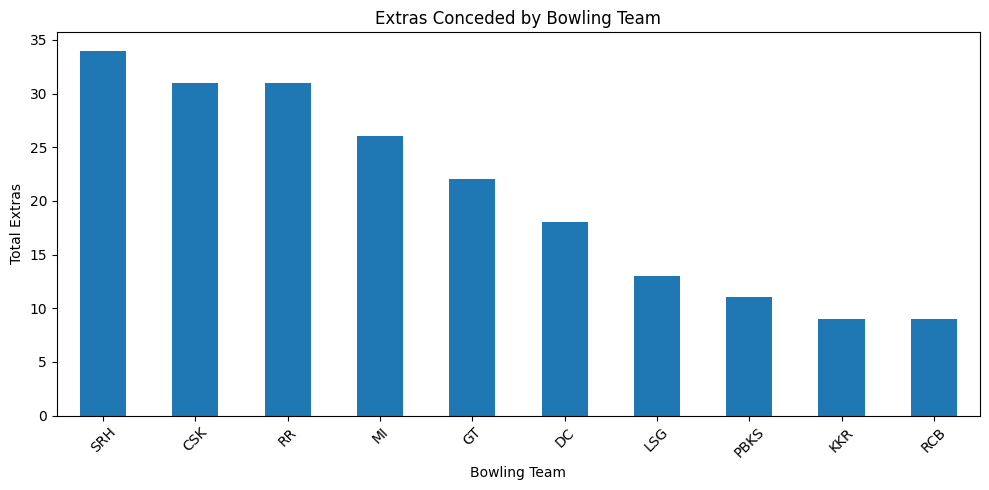

In [17]:
#3: Extras conceded by bowling team
try:
  plt.figure(figsize=(10, 5))
  team_extras = deliveries_cleaned.groupby('bowling_team')['extra_runs'].sum().sort_values(ascending=False)
  team_extras.plot(kind='bar', title='Extras Conceded by Bowling Team')
  plt.xlabel('Bowling Team')
  plt.ylabel('Total Extras')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
except Exception as ex:
  print("An error occured: ", ex)

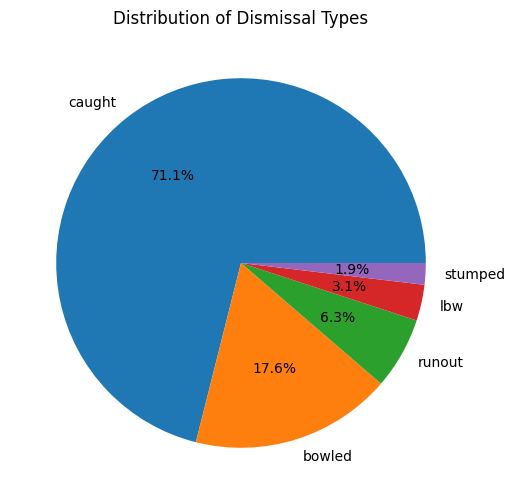

In [18]:
#4: Dismissal type distribution
try:
  plt.figure(figsize=(6, 6))
  dismissal_counts = deliveries_dataset['wicket_type'].value_counts()
  dismissal_counts.plot(kind='pie', autopct='%1.1f%%')
  plt.title('Distribution of Dismissal Types')
  plt.ylabel('')
  plt.show()
except Exception as ex:
  print("An error occured: ", ex)


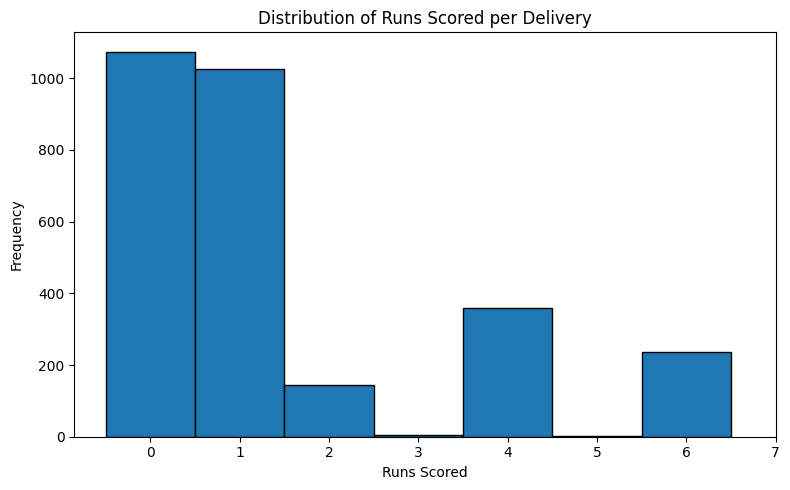

In [19]:
#5 Distribution of Runs Scored per Delivery
try:
  plt.figure(figsize=(8, 5))
  plt.hist(deliveries_cleaned['runs_scored_by_batsman'], bins=range(0, 8), edgecolor='black', align='left')
  plt.title("Distribution of Runs Scored per Delivery")
  plt.xlabel("Runs Scored")
  plt.ylabel("Frequency")
  plt.xticks(range(0, 8))
  plt.tight_layout()
  plt.show()
except Exception as ex:
  print("An error occured: ", ex)
